# Stage 1

Here you will find:

1. ML Canvas (stakeholders, business metrics, SLOs)
2. Exploratory Data Analysis (EDA)
3. Success metrics definitions
4. Baseline models exploration
5. MLflow Baseline Models Registration

## 1. ML Canvas

**Objective**

- Predict which telecom customers will churn (cancel service) so the retention team can intervene proactively.
- Binary classification: Churn = Yes / No.

**Success metric**

- Primary: PR-AUC >= 0.60.
- Secondaty: ROC-AUC >= 0.85.
- Tertiary: F1 >= 0.70 on the minority class (churners).
- Business KPI: reduce churn rate by 15% through targeted retention.

**Data**

- [Telco Customer Churn dataset (Kaggle)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn).
  - Size: 7,043 rows x 21 columns.
- Features:
  - demographics (gender, SeniorCitizen, Partner, Dependents)
  - account info (tenure, Contract, PaymentMethod, MonthlyCharges, TotalCharges)
  - services (InternetService, OnlineSecurity, TechSupport, StreamingTV, etc.).
- Target: Churn (Yes/No).

**Features**

- 19 input features after dropping customerID.
- Mix of numerical (tenure, MonthlyCharges, TotalCharges) and categorical (Contract, InternetService, PaymentMethod, etc.).

**Model**

- Baseline: Dummy Classifier and Logistic Regression.
- Primary: PyTorch MLP (Multi-Layer Perceptron).

**Constraints**

- Must run on CPU (no GPU requirement).
- API response time < 200ms.
- Model artifact must be serializable and versionable.

**Risks**

- Class imbalance (~26.5% churn).
- Small dataset (7K rows).
- Risk of overfitting with complex models.
- Possible data leakage if preprocessing isn't handled correctly.

## 2. Exploratory Data Analysis (EDA)

### 2.1. Data collection

Manual download of [Kaggle's Telco Customer Churn dataset]( https://www.kaggle.com/datasets/blastchar/telco-customer-churn) into `data/raw`.

```lang=shell
$ ls -l data/raw/
total 956
-rwxr-xr-x 1 thiago thiago 977501 Apr 18 13:05 WA_Fn-UseC_-Telco-Customer-Churn.csv
```

In [1]:
# add root to path, in order to use src/utils.py
import sys
sys.path.insert(0, '..')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils import set_seeds, get_logger

set_seeds(42)
logger = get_logger("eda")

# Load raw data
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
logger.info(f"Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns")

2026-04-18 19:06:18 | eda | INFO | Dataset loaded: 7043 rows x 21 columns


### 2.2. Initial inspection

Dataset size:

In [3]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 7043, Columns: 21


At a glance:

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Data types. It already reveals problems with:
- customerID: not useful
- SeniorCitizen: probably better to be categorical, but leave it for now
- TotalCharges: probably has strings
- Churn: yes or no should become 1 or 0

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
# Fix TotalCharges: blanks stored as strings
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Encode target: "Yes" -> 1, "No" -> 0
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Drop customerID — it's a unique identifier, not a feature
df.drop(columns=["customerID"], inplace=True)

logger.info(f"Columns after cleanup: {list(df.columns)}")

2026-04-18 19:06:18 | eda | INFO | Columns after cleanup: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


High level summary with percentiles:

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000
mean,0.162147,32.371149,64.761692,2283.300441,0.265370
std,0.368612,24.559481,30.090047,2266.771362,0.441561
min,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.500000,401.450000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.850000,3794.737500,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


### 2.3. Missing values

Count and visualize missing values:

In [8]:
missing = df.isnull().sum()
print(missing)

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


Impute with median:

In [9]:
total_charges_median = df["TotalCharges"].median()
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# sanity check
missing = df.isnull().sum()
print(missing[missing > 0])

Series([], dtype: int64)


Verify no missing values remain

In [10]:
assert df.isnull().sum().sum() == 0, "Still have missing values!"
logger.info("Missing values handled: TotalCharges median-imputed (11 rows)")

2026-04-18 19:06:19 | eda | INFO | Missing values handled: TotalCharges median-imputed (11 rows)


### 2.4. Target variable

Class distribution

In [11]:
print(df["Churn"].value_counts(normalize=True))

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


Visualizing class imbalance:

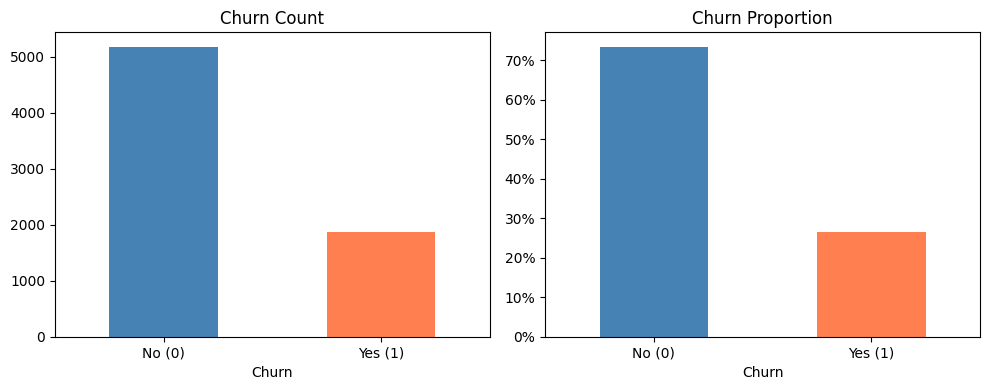

2026-04-18 19:06:19 | eda | INFO | Churn rate: 26.5%


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df["Churn"].value_counts().plot.bar(ax=axes[0], color=["steelblue", "coral"])
axes[0].set_title("Churn Count")
axes[0].set_xticklabels(["No (0)", "Yes (1)"], rotation=0)

df["Churn"].value_counts(normalize=True).plot.bar(ax=axes[1], color=["steelblue", "coral"])
axes[1].set_title("Churn Proportion")
axes[1].set_xticklabels(["No (0)", "Yes (1)"], rotation=0)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

plt.tight_layout()
plt.savefig("../docs/figures/target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

logger.info(f"Churn rate: {df['Churn'].mean():.1%}")

The target variable `Churn` has approximately 26.5% "Yes" and 73.5% "No".

This means a model that predicts "No" for every single customer achieves 73.5% accuracy.

**Balance ratio** = minority / majority = 0.265 / 0.735 = 0.36 approximately, moderate imbalance.

**Strategies for handling imbalanced data:**
1. **Stratified cross-validation** — Ensures each fold preserves the original class ratio.
2. **Threshold tuning** — Instead of the default 0.5 threshold, find the optimal cutoff for the business metric.
3. **Use appropriate metrics** — AUC-ROC and F1 instead of accuracy.

### 2.5. Outliers

Analyzing the numeric columns:

In [13]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols.remove("Churn")  # to avoid analyzing the target as a feature
print(num_cols)

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


**Z-score method:**

```
Z = (x - mean) / std
```

If |Z| > 3, the value is more than 3 standard deviations from the mean.

However, this method does not apply well here since:
- SeniorCitizen would have to be greater than 1.2 (max is 1)
- tenure would have to be greater than 106 months (max is 72)
- MonthlyCharges would have to be greater than 155 (max is 118)
- TotalCharges would have to be greater than 9077 (max is 8684)

In [14]:
for col in num_cols:
    # Calculate Z-score
    mean, std = df[col].mean(), df[col].std()
    min_v, max_v = df[col].min(), df[col].max()
    to_be_outlier = 3 * std + mean
    n_outliers = (((df[col] - mean) / std).abs() > 3).sum()

    print(f"{col}: to be outlier value has to be greater than {to_be_outlier:.4f}")
    print(f"mean={mean:.4f}, std={std:.4f}\nmin={min_v}, max={max_v}\noutliers={n_outliers}\n")

SeniorCitizen: to be outlier value has to be greater than 1.2680
mean=0.1621, std=0.3686
min=0, max=1
outliers=0

tenure: to be outlier value has to be greater than 106.0496
mean=32.3711, std=24.5595
min=0, max=72
outliers=0

MonthlyCharges: to be outlier value has to be greater than 155.0318
mean=64.7617, std=30.0900
min=18.25, max=118.75
outliers=0

TotalCharges: to be outlier value has to be greater than 9077.7281
mean=2281.9169, std=2265.2704
min=18.8, max=8684.8
outliers=0



**IQR (Interquartile Range) method:**

```
Q1 = 25th percentile
Q3 = 75th percentile
IQR = Q3 - Q1
Lower fence = Q1 - 1.5 x IQR
Upper fence = Q3 + 1.5 x IQR
```

Points outside the fences are outliers. This is exactly what boxplots visualize — the box spans Q1 to Q3, whiskers extend to the fences, and dots beyond are outliers. The IQR method is more robust than Z-score because it doesn't assume a normal distribution.

**Don't automatically delete outliers!** Consider the source:
- **Measurement error** — Remove or correct (e.g., negative age)
- **Legitimate extreme** — Cap at fence values or leave as-is (e.g., a customer with 72 months tenure is real)
- **Meaningful subpopulation** — Investigate further (e.g., very high charges might indicate enterprise customers)

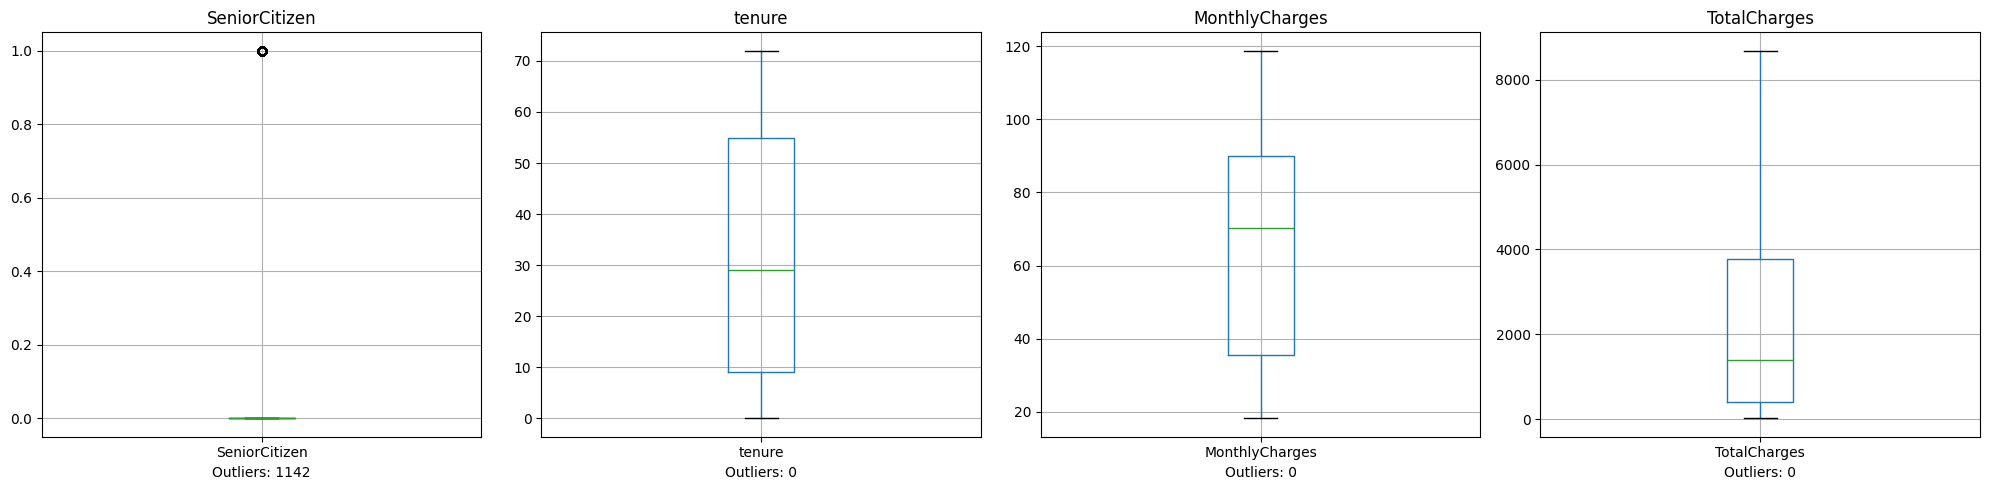

In [15]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 5))
for ax, col in zip(axes, num_cols):
    df.boxplot(column=col, ax=ax)
    ax.set_title(col)

    # Calculate IQR bounds
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    ax.set_xlabel(f"Outliers: {n_outliers}")

plt.tight_layout()
plt.savefig("../docs/figures/outliers_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

Decision: for this dataset, outliers in MonthlyCharges and TotalCharges represent legitimate high-value customers. We keep them as-is.

In [16]:
logger.info("Outlier analysis complete — no removal needed (legitimate extremes)")

2026-04-18 19:06:19 | eda | INFO | Outlier analysis complete — no removal needed (legitimate extremes)


### 2.6. Correlation

**Pearson correlation coefficient (r)** measures the linear relationship between two continuous variables:
- r = +1 — perfect positive linear relationship (as X increases, Y increases proportionally)
- r = 0 — no linear relationship (X and Y are independent, linearly)
- r = -1 — perfect negative linear relationship (as X increases, Y decreases proportionally)

**Correlation does not imply causation.** Two variables can be correlated without one causing the other.

**Multicollinearity** — High correlation between features (|r| > 0.8) means they carry redundant information. This causes problems for linear models:
- Coefficient estimates become unstable (small data changes lead to large coefficient swings)
- Interpretation becomes unreliable ("is it tenure or TotalCharges that matters?")
- Solutions: remove one feature, combine them (e.g., TotalCharges is roughly tenure x MonthlyCharges), or use regularization (L1/L2 penalty)

**Correlation between feature and target** indicates predictive power. High |r| with Churn means the feature is useful for the model.

Correlation matrix for numerical features + target:

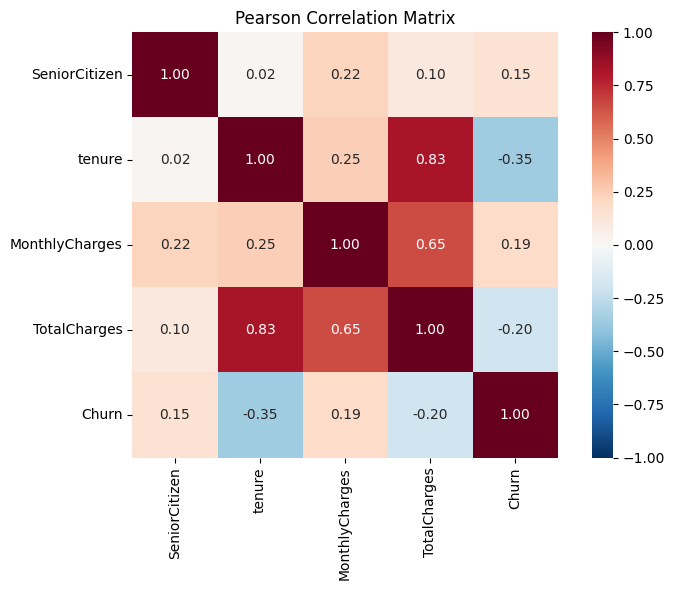

In [17]:
corr_cols = num_cols + ["Churn"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True)
plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.savefig("../docs/figures/correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

Key observations to note:

- TotalCharges and tenure:
  - high positive correlation: 0.83
  - hypothesis: expected since longer tenure = more total charges
- MonthlyCharges and Churn:
  - moderate positive correlation: 0.19
  - hypothesis: higher bills -> more likely to churn
- tenure and Churn:
  - moderate negative correlation: -0.35
  - hypothesis: longer customers -> less likely to churn

In [18]:
logger.info("Correlation analysis complete")

2026-04-18 19:06:20 | eda | INFO | Correlation analysis complete


### 2.7. Bivariate Analysis

Crosstab with `normalize="index"` shows the churn rate within each category of a feature.

This reveals which feature values are associated with higher churn, directly actionable business insights.

Analyzing the categoric columns:

In [19]:
cat_cols = df.select_dtypes(include="object").columns.tolist()

# consider SeniorCitizen categoric
cat_cols.append("SeniorCitizen")

print(len(cat_cols))
print(cat_cols)

16
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen']


In [20]:
for col in cat_cols:
    ct = pd.crosstab(df[col], df["Churn"], normalize="index")
    ct.columns = ["Retained", "Churned"]
    ct = ct.mul(100).round(1).astype(str) + "%"
    print(f"\n{col}\n" + "-" * 40)
    print(ct.to_string())


gender
----------------------------------------
       Retained Churned
gender                 
Female    73.1%   26.9%
Male      73.8%   26.2%

Partner
----------------------------------------
        Retained Churned
Partner                 
No         67.0%   33.0%
Yes        80.3%   19.7%

Dependents
----------------------------------------
           Retained Churned
Dependents                 
No            68.7%   31.3%
Yes           84.5%   15.5%

PhoneService
----------------------------------------
             Retained Churned
PhoneService                 
No              75.1%   24.9%
Yes             73.3%   26.7%

MultipleLines
----------------------------------------
                 Retained Churned
MultipleLines                    
No                  75.0%   25.0%
No phone service    75.1%   24.9%
Yes                 71.4%   28.6%

InternetService
----------------------------------------
                Retained Churned
InternetService                 
DSL            

Visualizing categoric column vs target:

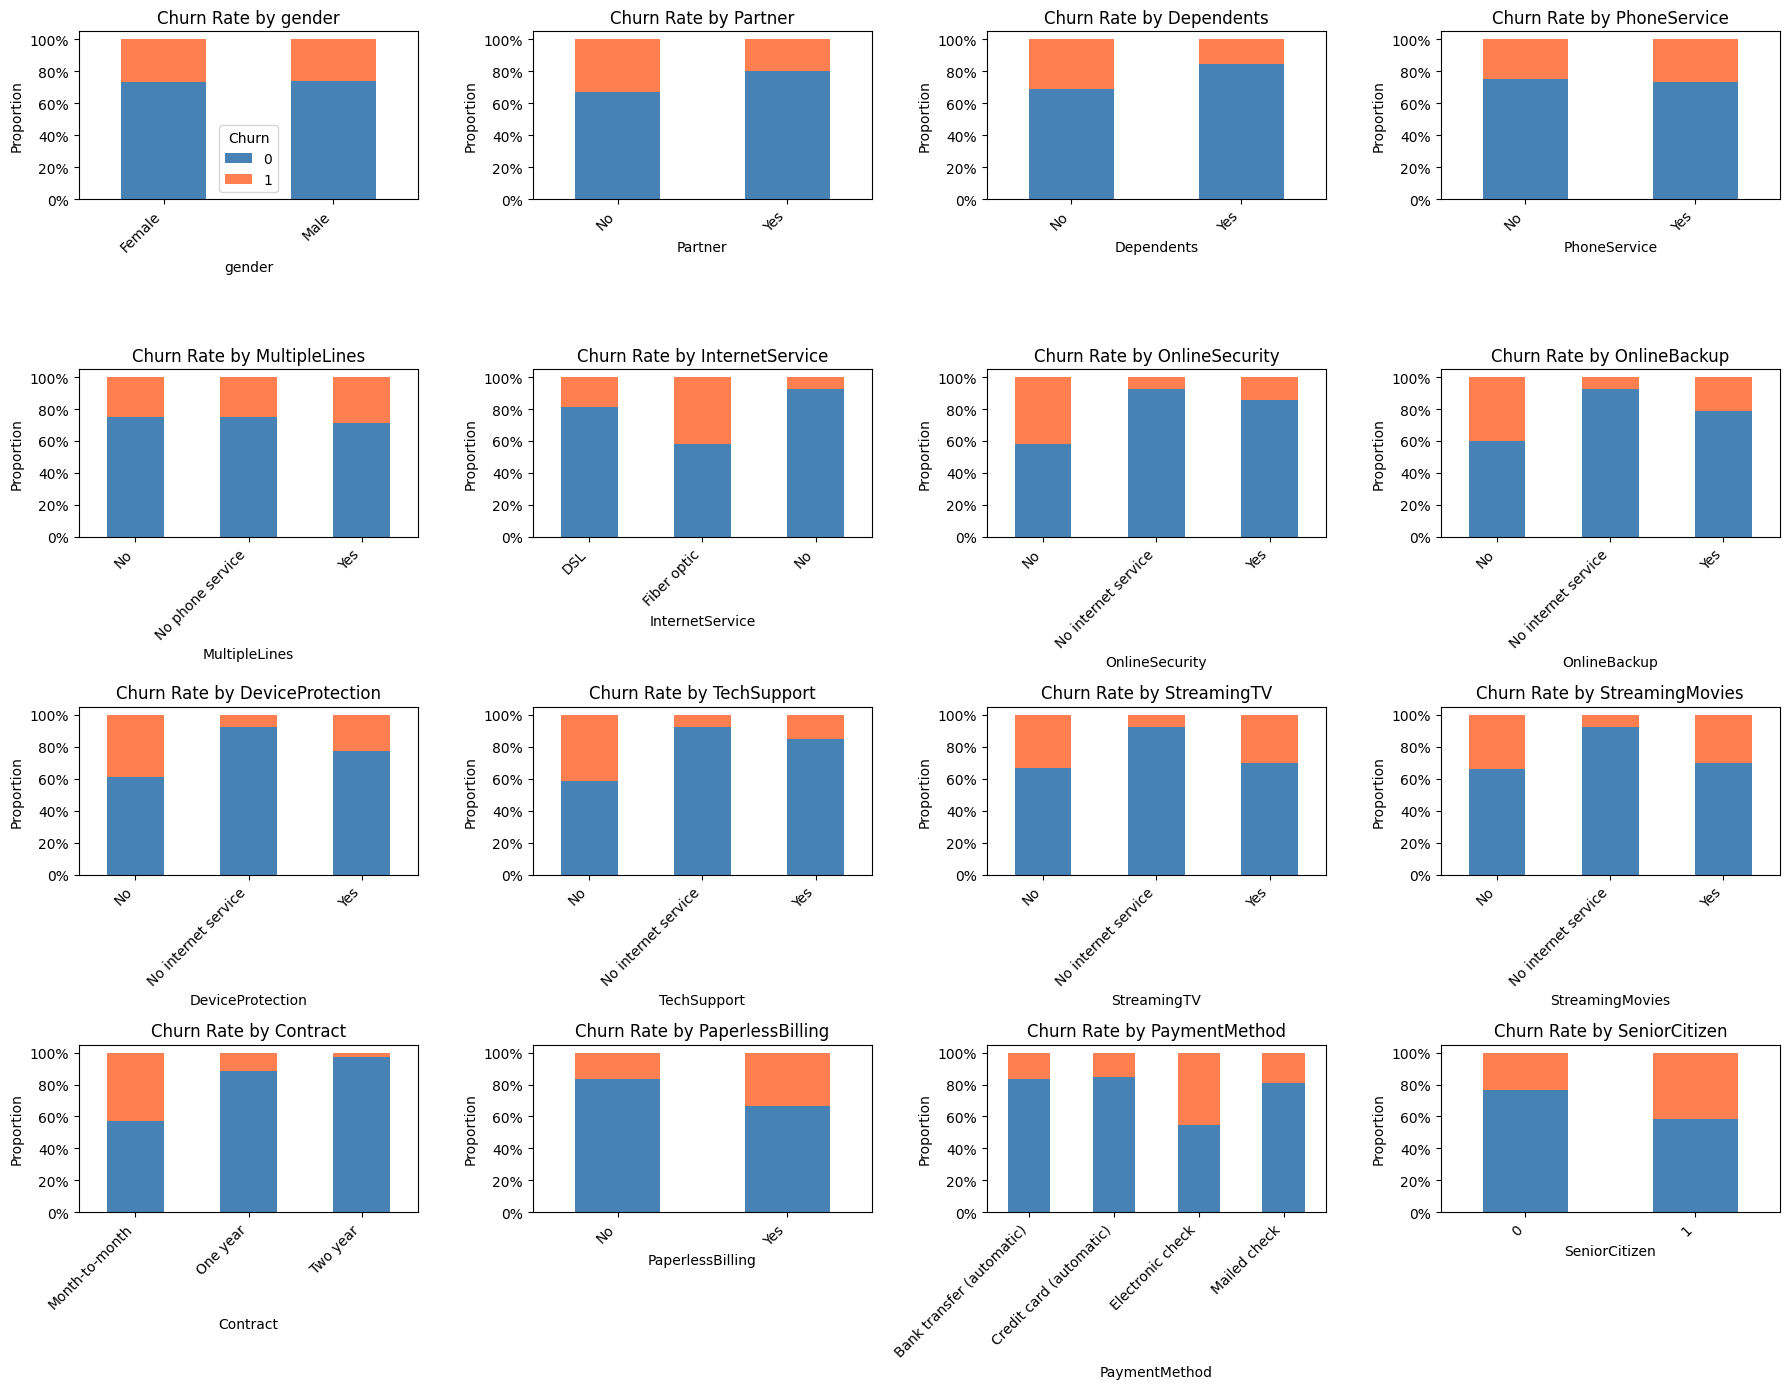

In [21]:
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df["Churn"], normalize="index")
    ct.plot.bar(stacked=True, ax=axes[i], color=["steelblue", "coral"],
                legend=(i == 0))
    axes[i].set_title(f"Churn Rate by {col}")
    axes[i].set_ylabel("Proportion")
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha="right")
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

# Hide unused subplots
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig("../docs/figures/bivariate_categorical.png", dpi=150, bbox_inches="tight")
plt.show()

Visualizing numerical column vs target:

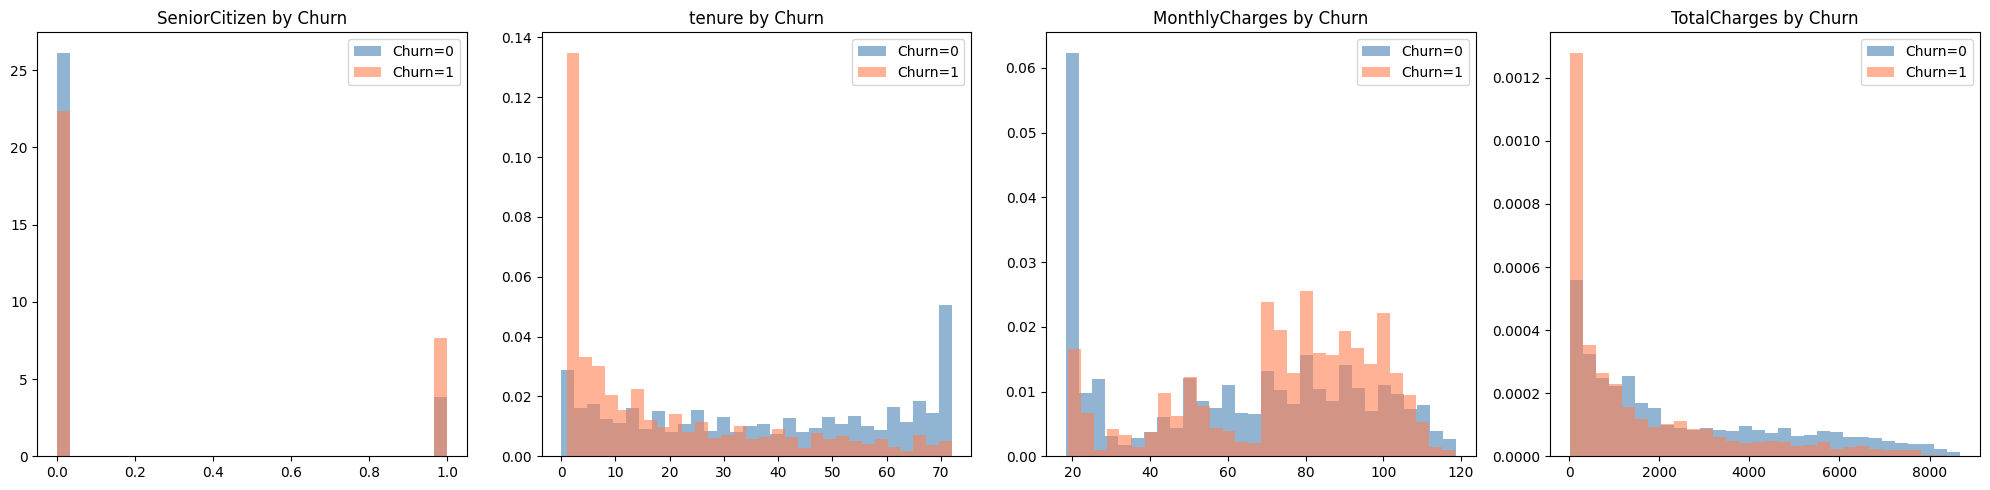

In [22]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 5))
for ax, col in zip(axes, num_cols):
    for label, color in [(0, "steelblue"), (1, "coral")]:
        subset = df[df["Churn"] == label][col]
        ax.hist(subset, bins=30, alpha=0.6, color=color,
                label=f"Churn={label}", density=True)
    ax.set_title(f"{col} by Churn")
    ax.legend()

plt.tight_layout()
plt.savefig("../docs/figures/bivariate_numerical.png", dpi=150, bbox_inches="tight")
plt.show()

Key observations to note:

- Contract type is the strongest predictor:
  - month-to-month customers churn at 42.7% vs just 2.8% for two-year contracts.
  - Biggest gap in the entire dataset.
- Payment method signals risk:
  - electronic check customers churn at 45.3%, nearly 3× the rate of automatic payment methods (~16%).
  - Likely correlated with month-to-month contracts.
- Fiber optic internet is a problem:
  - 41.9% churn vs 19% for DSL and 7.4% for no internet.
  - Could indicate pricing, service quality, or a customer segment mismatch.
- Add-on services strongly protect retention:
  - customers without OnlineSecurity, TechSupport, or OnlineBackup churn at ~40%, while those with them churn at ~15%.
  - The service bundle matters.
- Family anchor effect:
  - customers with a partner (19.7%) or dependents (15.5%) churn at roughly half the rate of single/no-dependent customers (~33%).
  - Stable life situation correlates with stable contracts.

In [23]:
logger.info("Bivariate analysis complete")

2026-04-18 19:06:22 | eda | INFO | Bivariate analysis complete


## 3. Success metrics definitions

**Confusion Matrix — the foundation of all classification metrics:**

Every binary classification prediction falls into one of four categories:

                      
|                  | Predicted Positive | Predicted Negative |
|------------------|--------------------|--------------------|
| Actual Positive  |    TP              |    FN              |
| Actual Negative  |    FP              |    TN              |


- **TP (True Positive)**: Model predicted churn, customer actually churned. Correct catch.
- **FP (False Positive)**: Model predicted churn, customer did NOT churn. False alarm, wasted retention effort.
- **FN (False Negative)**: Model predicted no churn, customer actually churned. Missed churner, the most costly error.
- **TN (True Negative)**: Model predicted no churn, customer did NOT churn. Correct dismissal.

From these four numbers, all classification metrics are derived:

- **Accuracy** = (TP + TN) / (TP + TN + FP + FN)
  - "Of all predictions, how many were correct?"
  - **MISLEADING on imbalanced data.**
  - A model predicting "No" for every customer gets 73.5% accuracy but catches zero churners.
- **Precision** = TP / (TP + FP)
  - "Of those flagged as churners, how many actually were?"
  - High precision = few false alarms.
  - Important when false positives are costly, e.g. each retention offer costs $50, don't want to waste offers on customers who weren't going to leave anyway.
- **Recall (Sensitivity)** = TP / (TP + FN)
  - "Of all actual churners, how many did I catch?"
  - High recall = few missed churners.
  - Important when false negatives are costly, e.g., each lost customer has a lifetime value of $5,000, so missing a churner is expensive.
- **F1-Score** = 2 x (Precision x Recall) / (Precision + Recall)
  - The harmonic mean of precision and recall. Why harmonic mean instead of arithmetic mean?
  - Because the harmonic mean penalizes imbalance between the two values:
    - If Precision = 1.0 and Recall = 0.01:
    - Arithmetic mean = (1.0 + 0.01) / 2 = 0.505 — looks acceptable
    - Harmonic mean = 2 x (1.0 x 0.01) / (1.0 + 0.01) = 0.0198 — reveals the problem
  - The F1 score is only high when BOTH precision and recall are high.
  - A model that catches all churners but also flags every non-churner (recall=1.0, precision=0.265) gets F1=0.42, not the misleading arithmetic average of 0.63.
- **ROC-AUC** (Receiver Operating Characteristic - Area Under the Curve):
  - The ROC curve plots True Positive Rate (recall) vs False Positive Rate (FP / (FP + TN)) at every possible classification threshold from 0.0 to 1.0.
    - At threshold = 0.0: everything is predicted positive. TPR = 1.0, FPR = 1.0 (top-right corner)
    - At threshold = 1.0: everything is predicted negative. TPR = 0.0, FPR = 0.0 (bottom-left corner)
    - Each threshold gives a different (FPR, TPR) point on the curve
  - AUC = area under this curve.
    - Random guessing = 0.5 (diagonal line from bottom-left to top-right)
    - Perfect model = 1.0 (goes straight up to (0, 1) then right to (1, 1))
    - Typical good model = 0.80 to 0.95
  - ROC-AUC is **threshold-independent**:
    - it evaluates ranking quality, not classification quality.
    - It answers: "Does the model generally assign higher scores to actual churners than to non-churners?"
    - This makes it a fair metric for comparing models before chosing a threshold.
- **PR-AUC** (Precision-Recall - Area Under the Curve):
  - Plots Precision vs Recall at every threshold. More informative than AUC-ROC on imbalanced data because it focuses on the positive (minority) class performance.
  - Key difference: the random baseline for PR-AUC is the class proportion (0.265 for our data), NOT 0.5.
  - So a PR-AUC of 0.50 on our dataset is meaningful — it's well above random.

**Metric table:**

| Metric | Target | Rationale |
|--------|--------|-----------|
| PR-AUC | >= 0.60 | Primary ranking metric, threshold-independent, standard for binary classification |
| ROC-AUC | >= 0.85 | Secondary ranking metric, threshold-independent, standard for binary classification |
| F1 (minority class) | >= 0.70 | Balances precision and recall on the class we care about (churners) |
| Precision | >= 0.65 | Controls false alarm rate — don't waste retention budget |
| Recall | >= 0.75 | Catches most churners — minimize missed revenue loss |
| Accuracy | Report only | For completeness, but not a decision metric due to class imbalance |

## 4. Baseline models exploration

### 4.1. Data Preprocessing Pipeline

#### 4.1.1. Scaling

**Gradient-based models** (Logistic Regression, Neural Networks): **NEED scaling.**

These models update weights using gradient descent, where the gradient magnitude depends on feature scale.

If `tenure` ranges 0-72 and `MonthlyCharges` ranges 18-118, the gradients for MonthlyCharges will be larger simply because the numbers are bigger, not because the feature is more important.

This causes the optimizer to take large steps in one direction and tiny steps in another, making convergence slow and unstable.

Scaling puts all features on equal footing.

**StandardScaler math:**

```
z = (x - mean) / std
```

- Subtracts the mean (centers the distribution at 0)
- Divides by the standard deviation (scales to unit variance)
- Result: each feature has mean approximately 0 and std approximately 1

**Critical rule:** Fit (compute mean and std) on TRAINING data only, then transform both train and test with the SAME mean and std. Fitting on all data leaks test set statistics into training, the model indirectly "sees" the test data during training, producing optimistically biased performance estimates.


#### 4.1.2. OneHotEncoder

Categorical variables like `Contract` have values {"Month-to-month", "One year", "Two year"}. It cannot be mapped to numbers (0, 1, 2) because that implies ordering: 2 > 1 > 0. The model would learn that "Two year" is somehow "greater than" "One year", which is meaningless for a category.

For N possible values, One-hot encoding creates N-1 binary columns:

```
Contract_One year:  [0 or 1]
Contract_Two year:  [0 or 1]
```

If both are 0, the original value was "Month-to-month", this is the reference category.

**Optimizations:**

**`handle_unknown="ignore"`**: If the API receives a category not seen during training (e.g., a new payment method), it creates all-zero columns instead of crashing. Essential for production robustness.

**`drop="if_binary"`**: drops the first category to avoid the **dummy variable trap** (perfect multicollinearity). With 2 categories and 2 binary columns, `column 2` = `1` - `column 1`. This causes problems for linear models (singular matrix, unstable coefficients). Dropping one column solves it with zero information loss. It could be done for columns that are not binary as well, but would it would conflict with **`handle_unknown="ignore"`**.


#### 4.1.3. ColumnTransformer

Applies different transformers to different column subsets in parallel:
- "num" pipeline: StandardScaler on numerical columns
- "cat" pipeline: OneHotEncoder on categorical columns

This is the scikit-learn way to build complex preprocessing that stays reproducible and leak-free.

#### 4.1.4. Preventing Data Leakage

Leakage = using information from the test set during training, making results artificially good. The model appears to perform well in development but fails in production because it was "cheating."

Common leak patterns:
1. **Scaling before splitting**: Fitting StandardScaler on the entire dataset before train/test split. The test set mean/std influence training data transformation.
2. **Feature engineering on full data**: Computing statistics (e.g., target encoding) using all rows including test set.
3. **Temporal leakage**: Using future information to predict the past (e.g., using "did the customer call support next week" to predict this week's churn).

Prevention: **Always split FIRST, then fit preprocessing on training data only.** The sklearn Pipeline handles this automatically, when it calls `pipeline.fit(X_train, y_train)`, it fits and transforms the training data; when it calls `pipeline.predict(X_test)`, it transforms (but does NOT re-fit) the test data.

### 4.2. Baseline models: Dummy Classifier and Logistic Regression

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score,
    average_precision_score, ConfusionMatrixDisplay, PrecisionRecallDisplay,
    RocCurveDisplay,
)

from src.data.preprocessing import load_and_split, build_preprocessor
from src.utils import set_seeds

set_seeds(42)
logger = get_logger("baseline")

def evaluate_model(model, X_test, y_test) -> dict:
    """Compute all metrics for a fitted model."""
    y_pred = model.predict(X_test)
    y_prob = (model.predict_proba(X_test)[:, 1]
              if hasattr(model, "predict_proba") else None)

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
    }
    if y_prob is not None:
        metrics["roc_auc"] = roc_auc_score(y_test, y_prob)
        metrics["pr_auc"] = average_precision_score(y_test, y_prob)

    return metrics

#### 4.2.1. Dummy Classifier

In [25]:
raw_data_filename = "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"
X_train, X_test, y_train, y_test = load_and_split(raw_data_filename)
preprocessor = build_preprocessor()

dummy_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent")),
])
dummy_pipe.fit(X_train, y_train)
metrics = evaluate_model(dummy_pipe, X_test, y_test)

logger.info(f"Dummy — Accuracy: {metrics['accuracy']:.3f}, "
            f"F1: {metrics['f1']:.3f}")

2026-04-18 19:06:22 | src.features.preprocessing | INFO | Split: train=5634, test=1409, churn_rate_train=0.265, churn_rate_test=0.265
2026-04-18 19:06:22 | src.features.preprocessing | INFO | TotalChargesFixer: learned median=1398.12
/home/thiago/fiap/churn-prediction/.env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
2026-04-18 19:06:22 | baseline | INFO | Dummy — Accuracy: 0.735, F1: 0.000


Confusion Matrix:

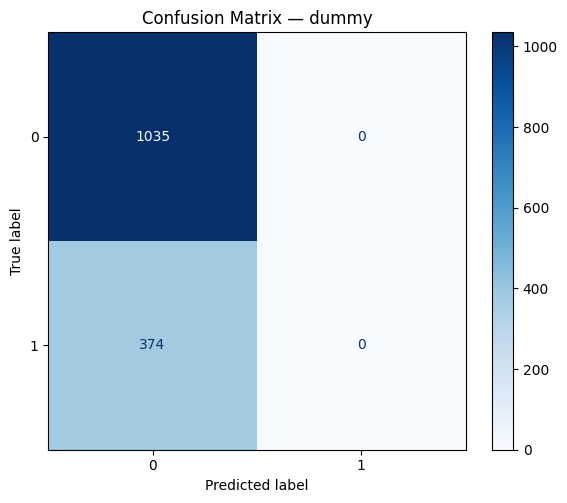

In [26]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(dummy_pipe, X_test, y_test,
                                      ax=ax, cmap="Blues")
ax.set_title(f"Confusion Matrix — dummy")

plt.tight_layout()
plt.savefig(f"../docs/figures/cm_dummy.png", dpi=150)
plt.show()

#### 4.2.2. Logistic Regression

In [29]:
preprocessor = build_preprocessor()

lr_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42,
    )),
])

# Cross-validation for reliable estimate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    lr_pipe, X_train, y_train, cv=cv,
    scoring=[
        "accuracy",
        "average_precision",  # pr_auc
        "f1",
        "roc_auc"
    ],
    return_train_score=False,
)

for metric_name in ["accuracy", "average_precision", "f1", "roc_auc"]:
    scores = cv_results[f"test_{metric_name}"]
    logger.info(f"LR CV {metric_name}: "
                f"{scores.mean():.3f} +/- {scores.std():.3f}")

# Fit on full training set for test evaluation
lr_pipe.fit(X_train, y_train)
test_metrics = evaluate_model(lr_pipe, X_test, y_test)

logger.info(f"LR Test — PR-AUC: {test_metrics.get('pr_auc', 'N/A'):.3f}, "
            f"ROC-AUC: {test_metrics.get('roc_auc', 'N/A'):.3f}, "
            f"F1: {test_metrics['f1']:.3f}")

2026-04-18 19:11:36 | src.features.preprocessing | INFO | TotalChargesFixer: learned median=1389.53
2026-04-18 19:11:36 | src.features.preprocessing | INFO | TotalChargesFixer: learned median=1396.90
2026-04-18 19:11:36 | src.features.preprocessing | INFO | TotalChargesFixer: learned median=1411.35
2026-04-18 19:11:36 | src.features.preprocessing | INFO | TotalChargesFixer: learned median=1396.25
2026-04-18 19:11:36 | src.features.preprocessing | INFO | TotalChargesFixer: learned median=1405.30
2026-04-18 19:11:37 | baseline | INFO | LR CV accuracy: 0.749 +/- 0.015
2026-04-18 19:11:37 | baseline | INFO | LR CV average_precision: 0.660 +/- 0.020
2026-04-18 19:11:37 | baseline | INFO | LR CV f1: 0.629 +/- 0.023
2026-04-18 19:11:37 | baseline | INFO | LR CV roc_auc: 0.846 +/- 0.012
2026-04-18 19:11:37 | src.features.preprocessing | INFO | TotalChargesFixer: learned median=1398.12
2026-04-18 19:11:37 | baseline | INFO | LR Test — PR-AUC: 0.633, ROC-AUC: 0.841, F1: 0.614


Confusion Matrix

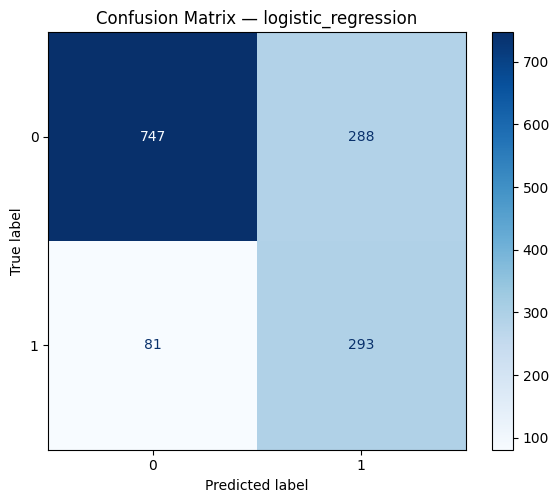

In [30]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(lr_pipe, X_test, y_test,
                                        ax=ax, cmap="Blues")
ax.set_title(f"Confusion Matrix — logistic_regression")

plt.tight_layout()
plt.savefig(f"../docs/figures/cm_logistic_regression.png", dpi=150)
plt.show()

PR-AUC and ROC-AUC curves:

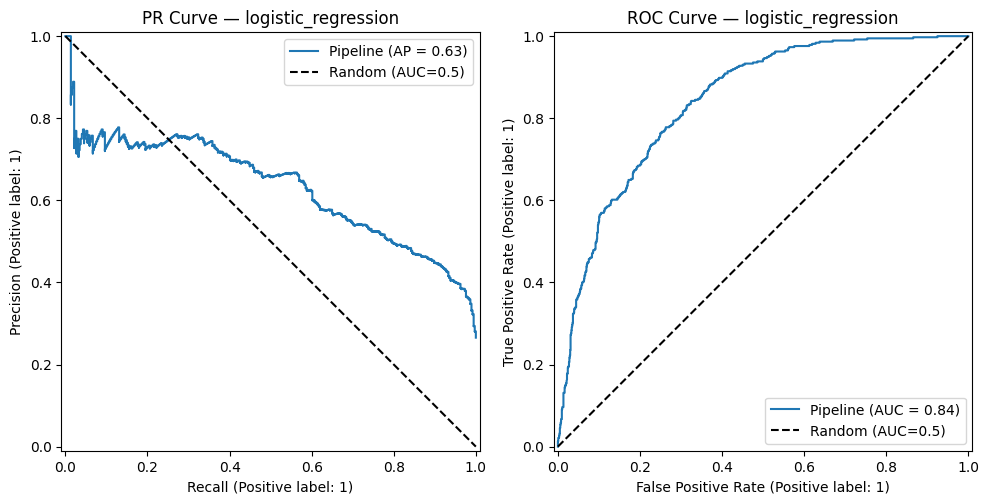

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

PrecisionRecallDisplay.from_estimator(lr_pipe, X_test, y_test, ax=axes[0])
axes[0].set_title(f"PR Curve — logistic_regression")
axes[0].plot([0, 1], [1, 0], "k--", label="Random (AUC=0.5)")
axes[0].legend()


RocCurveDisplay.from_estimator(lr_pipe, X_test, y_test, ax=axes[1])
axes[1].set_title(f"ROC Curve — logistic_regression")
axes[1].plot([0, 1], [0, 1], "k--", label="Random (AUC=0.5)")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"../docs/figures/auc_logistic_regression.png", dpi=150)
plt.show()

## 5. MLflow Baseline Models Registration

File: `src/models/baseline.py`

This script establishes two reference points before trying any complex model:

1. Dumb baseline (DummyClassifier): Always predicts the most common class, no learning at all. This sets the floor: any real model must beat this.
2. First real model (Logistic Regression): A simple, interpretable model that learns from the data. It uses class_weight="balanced" to handle the imbalance between churned and non-churned customers.

To get a reliable estimate of the logistic regression's performance, it uses 5-fold cross-validation, training and evaluating the model 5 times on different splits of the training data, then averaging the results. This avoids getting lucky (or unlucky) with a single train/test split.

Both models go through the same preprocessing pipeline, so the comparison is fair.

All results, metrics, charts (confusion matrix, ROC and PR curves), and the model itself, are automatically logged to MLflow for experiment tracking and reproducibility.

**Running the baselines**

Prepare the mlflow server in another terminal:

```lang=shell
$ mlflow ui --port 5001
Backend store URI not provided. Using sqlite:///mlflow.db
Registry store URI not provided. Using backend store URI.
2026/04/18 19:47:35 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/18 19:47:35 INFO mlflow.store.db.utils: Updating database tables
[MLflow] Security middleware enabled with default settings (localhost-only). To allow connections from other hosts, use --host 0.0.0.0 and configure --allowed-hosts and --cors-allowed-origins.
2026/04/18 19:47:36 INFO:     Uvicorn running on http://127.0.0.1:5001 (Press CTRL+C to quit)
2026/04/18 19:47:36 INFO:     Started parent process [17246]
2026/04/18 19:47:39 INFO:     Started server process [17249]
2026/04/18 19:47:39 INFO:     Waiting for application startup.
2026/04/18 19:47:39 INFO:     Application startup complete.
2026/04/18 19:47:39 INFO:     Started server process [17250]
2026/04/18 19:47:39 INFO:     Waiting for application startup.
2026/04/18 19:47:39 INFO:     Application startup complete.
2026/04/18 19:47:39 INFO:     Started server process [17252]
2026/04/18 19:47:39 INFO:     Waiting for application startup.
2026/04/18 19:47:39 INFO:     Application startup complete.
2026/04/18 19:47:39 INFO:     Started server process [17251]
2026/04/18 19:47:39 INFO:     Waiting for application startup.
2026/04/18 19:47:39 INFO:     Application startup complete.
2026/04/18 19:47:41 INFO mlflow.server.jobs.utils: Registered online_scoring_scheduler periodic task (runs every 1 minute)
```

Run the training script:

In [36]:
%cd ..
!python -m src.models.baseline

/home/thiago/fiap/churn-prediction
2026-04-18 19:53:03 | src.features.preprocessing | INFO | Split: train=5634, test=1409, churn_rate_train=0.265, churn_rate_test=0.265
2026/04/18 19:53:03 INFO mlflow.tracking.fluent: Experiment with name 'churn-baselines' does not exist. Creating a new experiment.
2026-04-18 19:53:04 | src.features.preprocessing | INFO | TotalChargesFixer: learned median=1398.12
/home/thiago/fiap/churn-prediction/.env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
2026-04-18 19:53:04 | __main__ | INFO | Dummy — Accuracy: 0.735, F1: 0.000
2026-04-18 19:53:04 | src.features.preprocessing | INFO | TotalChargesFixer: learned median=1389.53
2026-04-18 19:53:04 | src.features.preprocessing | INFO | TotalChargesFixer: learne

The results will be available in `http://localhost:5001/`:

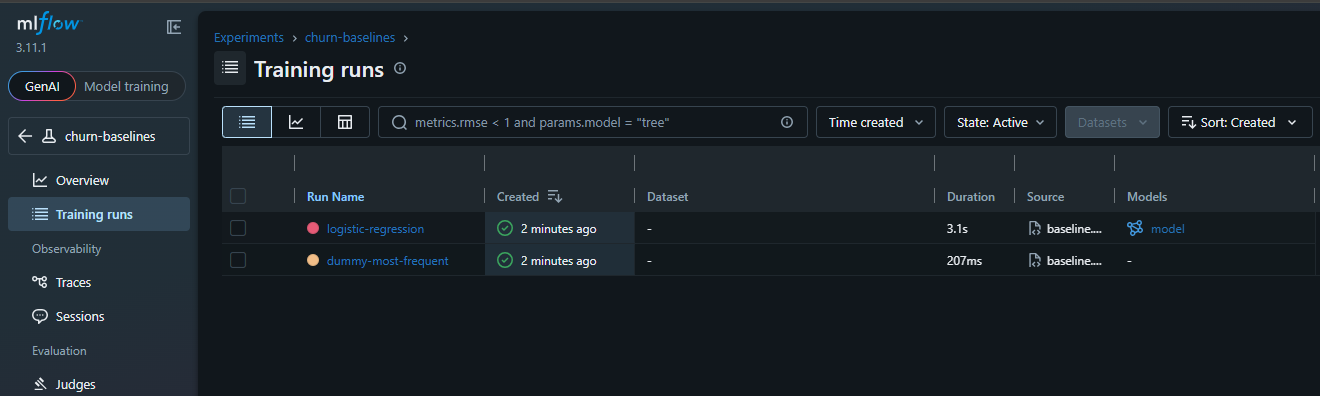